<a href="https://colab.research.google.com/github/dataprogpy/code-samples/blob/main/starter_files/07_robust_modeling_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Robust Modeling Workflow

In this lesson we extend the six-step workflow to introduce critical modeling best practices. In this session, we will move from classfication to regression.We will reuse the King County Housing dataset introduced in the last module for this purpose.

## Import required packages

In [2]:
# tools from standard library
import functools
from pathlib import Path

# tools for data wrangling
import numpy as np
import polars as pl

import geopandas as gpd

# plotting tools
import matplotlib.pyplot as plt

# pipeline and transformers
from sklearn.pipeline import (
    Pipeline,
    make_pipeline,
    )
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
    )
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor

# metrics for evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# cross validation and dataset splitter
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    validation_curve,
    GridSearchCV,
    KFold
    )
from sklearn.feature_selection import (
    RFECV,
    SelectKBest,
    f_regression,
    )

# base types for custom transformer
from sklearn.base import BaseEstimator, TransformerMixin

# sklearn config to outpur polars dataframes
from sklearn import set_config
set_config(transform_output='polars')


## Import and clean data

In [3]:
data_root = Path("/content/drive/MyDrive/dataprogpy/data")
house_data_path = Path("kc_house_data.csv")
schdst_file_path = Path("School_Districts_in_King_County___schdst_area/School_Districts_in_King_County___schdst_area.shp")

In [4]:
kc_schdst = gpd.read_file(data_root / schdst_file_path) # school district shapes

In [5]:
# Load the dataset
raw = pl.read_csv(data_root / house_data_path)
print(kc_schdst.columns)
raw.head()

Index(['OBJECTID', 'SCHDST', 'NAME', 'DSTNUM', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')


id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
i64,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64
7129300520,"""20141013T000000""",221900.0,3,1.0,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,"""20141209T000000""",538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.721,-122.319,1690,7639
5631500400,"""20150225T000000""",180000.0,2,1.0,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,"""20141209T000000""",604000.0,4,3.0,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,"""20150218T000000""",510000.0,3,2.0,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
raw_pd = raw.to_pandas()
raw_pd = gpd.GeoDataFrame(
        raw_pd,
        geometry=gpd.points_from_xy(raw_pd.long, raw_pd.lat),
        crs="EPSG:4326"
        ).sjoin(
            kc_schdst.to_crs("EPSG:4326"),
            how="left",
            predicate="intersects")
print(f"raw_pd.shape:{raw_pd.shape}")
# raw_pd.head()
raw = pl.from_pandas(raw_pd[raw.columns + ["NAME"]]).select(
    pl.col(raw.columns),
    pl.col("NAME").alias("school_district")
)
print(f"raw.shape:{raw.shape}")
print(f"raw.columns: {raw.columns}")
raw.head()

raw_pd.shape:(21613, 29)
raw.shape:(21613, 22)
raw.columns: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'school_district']


id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,school_district
i64,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,str
7129300520,"""20141013T000000""",221900.0,3,1.0,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,"""Seattle"""
6414100192,"""20141209T000000""",538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.721,-122.319,1690,7639,"""Seattle"""
5631500400,"""20150225T000000""",180000.0,2,1.0,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,"""Northshore"""
2487200875,"""20141209T000000""",604000.0,4,3.0,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,"""Seattle"""
1954400510,"""20150218T000000""",510000.0,3,2.0,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,"""Lake Washington"""


## Define preprocessing transformers

### Function transformer

In [7]:
def tweak_housing(df):
    return (
        df.with_columns(
            zipcode=pl.col('zipcode').cast(pl.String).cast(pl.Categorical),
            school_district=pl.col('school_district').cast(pl.Categorical),
            date=pl.col('date').str.strptime(pl.Date, format="%Y%m%dT%H%M%S"),
            yr_renovated=pl.col('yr_renovated').replace(0, None),
            ).select(
                pl.col(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'school_district','lat', 'long', 'sqft_living15', 'sqft_lot15', 'date', ])
            )
    )

tweak_transformer = FunctionTransformer(tweak_housing)

### Preprocess numeric features

In [8]:
numeric_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                    'floors', 'waterfront', 'view', 'condition', 'grade',
                    'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
                    'lat', 'long', 'sqft_living15', 'sqft_lot15', ]

numeric_transformer = Pipeline(
    steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])

### Preprocess categorical features

In [9]:
categorical_features = [
    # 'zipcode',
    'school_district',
    ]

categorical_transformer = Pipeline(
    steps=[
         ('onehot', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False)),
    # ('target', TargetEncoder()),
    # ('std', StandardScaler()),
    ])

### Compose preprocessor

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat',categorical_transformer, categorical_features),
        ],
        # remainder='passthrough',
    )

## Construct modeling pipeline

In [11]:
def train_test(model, test_size=0.4, random_state=42):
  X = raw
  y = raw.select('price')

  X_train, X_test, y_train, y_test = train_test_split(
      X,
      y,
      test_size=test_size,
      random_state=random_state)

  pipeline = make_pipeline(tweak_transformer, preprocessor, model)
  pipeline.fit(X_train, y_train)
  print(pipeline.score(X_test, y_test))
  return pipeline

### Dummy regressor pipeline

In [12]:
train_test(DummyRegressor(strategy='median'), 0.4,)

-0.0597493285675994


Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function tweak_housing at 0x7a42624553a0>)),
                ('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'waterfront',
                                                   'view', 'condition', 'grade',
                                                   'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'lat',
                                                   'long', 'sqft_living15',
                                                   'sqft_lot15']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['school_district'])])),
                ('dummyregressor', DummyRegressor(strategy='median'))])

### Linear regression pipeline

In [13]:
train_test(LinearRegression(), 0.4,)

0.7399756977611396


Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function tweak_housing at 0x7a42624553a0>)),
                ('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'waterfront',
                                                   'view', 'condition', 'grade',
                                                   'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'lat',
                                                   'long', 'sqft_living15',
                                                   'sqft_lot15']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['school_district'])])),
                ('linearregression', LinearRegression())])

### Decision tree regression pipeline

In [14]:
dt_pipe = train_test(DecisionTreeRegressor(max_depth=5, random_state=42), 0.6,)

0.7030456706161811


## Hyperparameter Tuning

### Make pipeline and fit data

In [22]:
X = raw
y = raw.select('price')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
    )
dt_pipe = make_pipeline(
    tweak_transformer,
    preprocessor,
    DecisionTreeRegressor(random_state=42)
    )
dt_pipe.fit(X_train, y_train)

print(dt_pipe.named_steps['decisiontreeregressor'].get_depth())
dt_pipe.score(X_test, y_test)

34


0.7202446350719095

### Perform cross validation

In [16]:
param = "decisiontreeregressor__max_depth"
param_range = range(1, 20)
train_scores, test_scores = validation_curve(
    dt_pipe,
    X_train,
    y_train,
    param_name=param,
    param_range=param_range,
    scoring="neg_mean_squared_error",
    n_jobs=1)

### Plotting validation curve

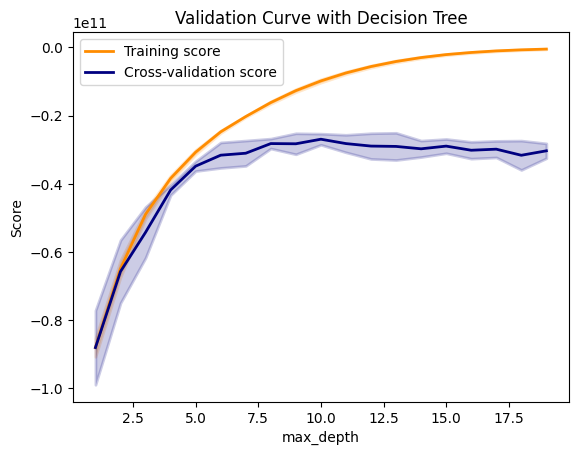

In [17]:
# make a validation curve from train_scores and test_scores

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.title("Validation Curve with Decision Tree")
plt.xlabel("max_depth")
plt.ylabel("Score")
#plt.ylim(-1, 0)
lw = 2
plt.plot(param_range, train_scores_mean, label="Training score",
             color="darkorange", lw=lw)
plt.fill_between(param_range, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2,
                 color="darkorange", lw=lw)
plt.plot(param_range, test_scores_mean, label="Cross-validation score",
                color="navy", lw=lw)

plt.fill_between(param_range, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.2,
                    color="navy", lw=lw)
plt.legend(loc="best")

### Grid Search
Searching for best hyperparameter values for multiple hyperparameters

In [19]:
param_grid = {
    f'{"DecisionTreeRegressor".lower()}__max_depth': [3, 6, 9],
    f'{"DecisionTreeRegressor".lower()}__min_samples_split': [10, 20, 100],
    f'{"DecisionTreeRegressor".lower()}__min_samples_leaf': [10, 20, 100],
}
dt_pipe = make_pipeline(
    tweak_transformer,
    preprocessor,
    DecisionTreeRegressor(random_state=42)
    )
grid_search = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=1 # This will print progress updates
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('functiontransformer',
                                        FunctionTransformer(func=<function tweak_housing at 0x7a42624553a0>)),
                                       ('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['bedrooms',
                                                                          'bathrooms',
                                                                          'sqft_living',
                                                                          'sqft_lot',
                                                                          'floors',
                                                                          'waterf...
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['school_district'])])),
                                       ('decisiontreeregressor',
                                        DecisionTreeRegressor(random_state=42))]),
             param_grid={'decisiontreeregressor__max_depth': [3, 6, 9],
                         'decisiontreeregressor__min_samples_leaf': [10, 20,
                                                                     100],
                         'decisiontreeregressor__min_samples_split': [10, 20,
                                                                      100]},
             scoring='neg_mean_absolute_error', verbose=1)

In [20]:
pl.DataFrame(grid_search.best_params_)

decisiontreeregressor__max_depth,decisiontreeregressor__min_samples_leaf,decisiontreeregressor__min_samples_split
i64,i64,i64
9,10,10


In [21]:
dt_pipe = make_pipeline(
    tweak_transformer,
    preprocessor,
    DecisionTreeRegressor(random_state=42))
dt_pipe.set_params(**grid_search.best_params_)
dt_pipe.fit(X_train, y_train)
dt_pipe.score(X_test, y_test)

0.7418494835664584

In [ ]:
grid_search = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=1 # This will print progress updates
)
# Print the best hyperparameters found
print("Best Hyperparameters:")
print(grid_search.best_params_)

# The best score is negative, so we multiply by -1 to get the MAE
best_mae = -grid_search.best_score_
print(f"\nBest Cross-Validated MAE: ${best_mae:,.2f}")

final_predictions = grid_search.predict(X_test)

## Building and tuning ensemble models

## References

1. [Comparing cross-validation strategies](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html)
1. [Applied Machine Learning: Foundations](https://www.linkedin.com/learning/applied-machine-learning-foundations-21404006) - LinkedIn Learning course